# ClearPath DQR + Cleaning Pipeline

**Data Source**: Docker MySQL `clearpath` (loaded by `database_build.ipynb`)

**Structure**: Standard 7-module DQR — Executive Summary → Data Profiling → Quality Dimensions → Anomaly Detection → DQ Score → Cleaning Pipeline → Action Items → Appendix

**Target ML**: Busyness prediction (time series + user reports)

**Plan**: See `dqr_plan.md`

---
## Part 0: Configuration & DB Connection

In [ ]:
import sys
import os
import json
import re
from pathlib import Path
from datetime import datetime
from math import radians, sin, cos, sqrt, atan2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

# ── Import shared utilities (from database_build.ipynb's directory) ──
UTIL_DIR = Path.cwd().resolve().parents[1] / '6.2-6.5_DB'
sys.path.insert(0, str(UTIL_DIR))
from dqr_utils import get_conn, is_manhattan, gps_to_district, validate_coords, haversine_m, gen_vid, source_hash, MANHATTAN_BOUNDS

# ── Output directory ──
OUTPUT_DIR = Path.cwd()
OUTPUT_DIR.mkdir(exist_ok=True)

# ── API Config ──
SODA_BASE = 'https://data.cityofnewyork.us/resource/7ym2-wayt.json'
TOMTOM_API_KEY = os.environ.get('TOMTOM_API_KEY', 'YOUR_KEY_HERE')
TOMTOM_FLOW_URL = 'https://api.tomtom.com/traffic/services/4/flowSegmentData/absolute/10/json'
NWS_HEADERS = {'User-Agent': 'ClearPath-DQR/1.0 (research-project)'}

# ── DQR Scope Tables ──
DQR_TABLES = [
    'venues', 'restroom_profiles', 'healthcare_profiles',
    'emergency_assets', 'pedestrian_ramps', 'venue_source_links',
    'busyness_scores', 'external_context_cache', 'user_reports'
]

# ── Connect to MySQL ──
try:
    conn = get_conn()
    with conn.cursor() as cur:
        cur.execute('SELECT COUNT(*) FROM venues')
        venue_count = cur.fetchone()[0]
    print(f'MySQL connection OK — {venue_count} venues in database')
except Exception as e:
    print(f'MySQL connection failed: {e}')
    print('Make sure docker-compose up -d mysql is running and data is loaded.')

print(f'Output dir: {OUTPUT_DIR}')
print(f'Timestamp:  {datetime.now().isoformat()}')

MySQL connection OK — 4841 venues in database
Output dir: /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.8-6.12_DB
Timestamp:  2026-06-09T16:54:27.895754


---
## 1. Executive Summary

In [6]:
# ── 1.1 Load all DQR tables into DataFrames ──
def query_table(table, conn, extra=''):
    """Query a table into a DataFrame."""
    sql = f'SELECT * FROM {table} {extra}'
    return pd.read_sql(sql, conn)

data = {}
for table in DQR_TABLES:
    try:
        df = query_table(table, conn)
        data[table] = df
        print(f'{table:30s} → {len(df):>6,} rows, {len(df.columns):>2} cols')
    except Exception as e:
        print(f'{table:30s} → ERROR: {e}')
        data[table] = pd.DataFrame()

venues                         →  4,841 rows, 24 cols
restroom_profiles              →    476 rows, 10 cols
healthcare_profiles            →  1,086 rows,  9 cols
emergency_assets               →  3,279 rows, 10 cols
pedestrian_ramps               → 23,625 rows, 17 cols
venue_source_links             →  4,841 rows,  9 cols
busyness_scores                →      0 rows, 11 cols
external_context_cache         →      1 rows,  8 cols


In [7]:
# ── 1.2 Executive Summary ──
venues_df = data.get('venues', pd.DataFrame())
total_rows = sum(len(df) for df in data.values() if not df.empty)
tables_loaded = sum(1 for df in data.values() if not df.empty)
tables_empty = sum(1 for df in data.values() if df.empty)

# Venue type distribution
if not venues_df.empty and 'venue_type' in venues_df.columns:
    vt_dist = venues_df['venue_type'].value_counts().to_dict()
else:
    vt_dist = {}

# Overall completeness (venues table)
if not venues_df.empty:
    overall_null_pct = venues_df.isnull().mean().mean() * 100
    overall_completeness = 100 - overall_null_pct
else:
    overall_completeness = 0

print('=' * 60)
print('  EXECUTIVE SUMMARY — ClearPath DQR')
print('=' * 60)
print(f'  数据库:       clearpath (Docker MySQL)')
print(f'  总行数:       {total_rows:,}')
print(f'  表加载:       {tables_loaded} / {len(DQR_TABLES)} (scope), {tables_empty} empty')
print(f'  场馆总数:     {len(venues_df):,}')
print(f'  场馆类型:     {vt_dist}')
print(f'  完整率:       {overall_completeness:.1f}% (venues table)')
print(f'  评估日期:     {datetime.now().strftime("%Y-%m-%d")}')
print(f'  评估范围:     Manhattan + busyness prediction 相关表')
print('=' * 60)

  EXECUTIVE SUMMARY — ClearPath DQR
  数据库:       clearpath (Docker MySQL)
  总行数:       38,149
  表加载:       7 / 8 (scope), 1 empty
  场馆总数:     4,841
  场馆类型:     {'emergency_asset': 3279, 'healthcare': 1086, 'restroom': 476}
  完整率:       63.4% (venues table)
  评估日期:     2026-06-09
  评估范围:     Manhattan + busyness prediction 相关表


---
## 2. Data Profiling

In [8]:
# ── 2.1 Column-level Analysis ──
def column_profile(df, table_name):
    """Column-level profiling: dtype, non-null rate, unique, min/max/mode."""
    results = []
    for col in df.columns:
        s = df[col]
        total = len(s)
        non_null = s.notna().sum()
        missing_pct = round((1 - non_null / total) * 100, 1) if total > 0 else 0
        nunique = s.nunique()
        mode_val = s.mode().iloc[0] if not s.mode().empty else None

        min_val = max_val = mean_val = std_val = None
        if pd.api.types.is_numeric_dtype(s):
            min_val = s.min()
            max_val = s.max()
            mean_val = round(s.mean(), 2) if s.notna().any() else None
            std_val = round(s.std(), 2) if s.notna().sum() > 1 else None

        results.append({
            'table': table_name, 'column': col,
            'dtype': str(s.dtype), 'non_null': non_null, 'total': total,
            'missing_pct': missing_pct, 'nunique': nunique,
            'mode': str(mode_val)[:50] if mode_val is not None else None,
            'min': min_val, 'max': max_val, 'mean': mean_val, 'std': std_val
        })
    return pd.DataFrame(results)

all_profiles = pd.concat(
    [column_profile(df, name) for name, df in data.items() if not df.empty],
    ignore_index=True
)
print(f'Column profiling: {len(all_profiles)} fields across {tables_loaded} tables')
all_profiles.to_csv(OUTPUT_DIR / 'dqr_field_summary.csv', index=False)
print('→ Saved: dqr_field_summary.csv')

Column profiling: 87 fields across 7 tables
→ Saved: dqr_field_summary.csv


In [10]:
# ── 2.1d healthcare_profiles Feature Profile ──
hp = data.get('healthcare_profiles', pd.DataFrame())
if not hp.empty:
    profile_rows = []
    for c in hp.columns:
        s = hp[c]
        non_null_count = int(s.notna().sum())
        cardinality = int(s.nunique(dropna=True))

        vc = s.value_counts(dropna=True).head(5)
        top5_values = ' | '.join([str(v) for v in vc.index])
        top5_counts = ' | '.join([str(int(v)) for v in vc.values])
        top5_freq = ' | '.join([
            str(round((int(v) / non_null_count) * 100, 2)) if non_null_count > 0 else '0.0'
            for v in vc.values
        ])

        profile_rows.append({
            'feature': c,
            'non_null_count': non_null_count,
            'cardinality': cardinality,
            'top5_values': top5_values,
            'top5_counts': top5_counts,
            'top5_freq_%': top5_freq
        })

    profile_df = pd.DataFrame(profile_rows).sort_values(['cardinality', 'non_null_count'], ascending=[False, False])
    print(f'=== healthcare_profiles Feature Profile ({len(profile_df)} cols, {len(hp)} rows) ===')
    display(profile_df)
else:
    print('healthcare_profiles is empty — skipping feature profile')

=== healthcare_profiles Feature Profile (9 cols, 1086 rows) ===


,feature,non_null_count,cardinality,top5_values,top5_counts,top5_freq_%
0,venue_id,1086,1086,0006c1aef358bc9d07ac1a05258679fbfa71 | a6ff1fe...,1 | 1 | 1 | 1 | 1,0.09 | 0.09 | 0.09 | 0.09 | 0.09
1,facility_external_id,431,431,15615 | 15577 | 7066 | 10111 | 9173,1 | 1 | 1 | 1 | 1,0.23 | 0.23 | 0.23 | 0.23 | 0.23
5,operator_name,431,213,NYU Langone Hospitals | The New York and Presb...,29 | 23 | 18 | 16 | 13,6.73 | 5.34 | 4.18 | 3.71 | 3.02
4,healthcare_speciality,151,64,dermatology | plastic_surgery | gynaecology | ...,16 | 12 | 10 | 8 | 7,10.6 | 7.95 | 6.62 | 5.3 | 4.64
2,facility_type,1051,17,pharmacy | clinic | dentist | LHCSA | DTC-EC,284 | 246 | 96 | 88 | 80,27.02 | 23.41 | 9.13 | 8.37 | 7.61
6,ownership_type,431,6,Not for Profit Corporation | Business Corporat...,272 | 72 | 65 | 20 | 1,63.11 | 16.71 | 15.08 | 4.64 | 0.23
3,healthcare_category,1086,4,clinic | pharmacy | hospital | dentist,558 | 284 | 148 | 96,51.38 | 26.15 | 13.63 | 8.84
8,official_source_priority,1086,2,2 | 1,655 | 431,60.31 | 39.69
7,main_site_name,0,0,,,


### Expected User Report Event Types

The `user_reports` table uses these event types (runtime data, currently empty in DB).
Canonical values from `openapi.yaml` `ReportSubmission.issue_type` enum:

| Event Type (snake_case) | Description |
|---|---|
| `elevator_broken` | Elevator/lift malfunction |
| `wheelchair_lift_broken` | Wheelchair lift malfunction |
| `toilet_out_of_order` | Restroom not operational |
| `large_crowd` | Venue overcrowding |
| `protest_or_blockage` | Protest or event blocking access |
| `entrance_closed` | Access point obstructed/closed |
| `ramp_blocked` | Wheelchair ramp obstructed |
| `closed_early` | Venue closed before posted hours |

In [ ]:
# ── 2.1e User Report Event Types (reference + validation) ──
# Canonical values from openapi.yaml ReportSubmission.issue_type enum
EXPECTED_EVENT_TYPES = {
    'elevator_broken',          # Elevator/lift malfunction
    'wheelchair_lift_broken',   # Wheelchair lift malfunction
    'toilet_out_of_order',      # Restroom not operational
    'large_crowd',              # Venue overcrowding
    'protest_or_blockage',      # Protest or event blocking access
    'entrance_closed',          # Access point obstructed/closed
    'ramp_blocked',             # Wheelchair ramp obstructed
    'closed_early',             # Venue closed before posted hours
}

ur = data.get("user_reports", pd.DataFrame())
if not ur.empty and "issue_type" in ur.columns:
    actual = set(ur["issue_type"].dropna().unique())
    known = actual & EXPECTED_EVENT_TYPES
    unknown = actual - EXPECTED_EVENT_TYPES
    missing = EXPECTED_EVENT_TYPES - actual
    print(f"=== User Report Event Types ===")
    print(f"  Total records:    {len(ur)}")
    print(f"  Event types:      {len(actual)} found, {len(EXPECTED_EVENT_TYPES)} expected")
    print(f"  Known types:      {sorted(known)}")
    if unknown:
        print(f"  ⚠ Unknown types:   {sorted(unknown)}")
    if missing:
        print(f"  Missing types:    {sorted(missing)}")
    print()
    for evt, cnt in ur["issue_type"].value_counts().items():
        print(f"    {evt:<30} {cnt:>6} ({cnt/len(ur)*100:.1f}%)")
else:
    print(f"=== User Report Event Types (reference) ===")
    print(f"  user_reports is empty (runtime table) — listing expected types:")
    for evt in sorted(EXPECTED_EVENT_TYPES):
        print(f"    • {evt}")

In [7]:
# ── 2.2 Row-level Analysis ──
row_stats = []
for name, df in data.items():
    if df.empty:
        continue
    total = len(df)
    fully_null = df.isnull().all(axis=1).sum()
    dup_rows = df.duplicated().sum()
    # Coordinate outlier check (if lat/lng present)
    coord_outliers = 0
    for lat_col in ['latitude']:
        for lng_col in ['longitude']:
            if lat_col in df.columns and lng_col in df.columns:
                valid = df.dropna(subset=[lat_col, lng_col])
                coord_outliers = (~valid.apply(
                    lambda r: is_manhattan(float(r[lat_col]), float(r[lng_col])),
                    axis=1)).sum()
    row_stats.append({
        'table': name, 'total': total,
        'fully_null_rows': fully_null, 'duplicate_rows': dup_rows,
        'coord_outliers': coord_outliers
    })

row_stats_df = pd.DataFrame(row_stats)
print(row_stats_df.to_string(index=False))

                 table  total  fully_null_rows  duplicate_rows  coord_outliers
                venues   4841                0               0             167
     restroom_profiles    476                0               0               0
   healthcare_profiles   1086                0               0               0
      emergency_assets   3279                0               0               0
      pedestrian_ramps  23625                0               0              27
    venue_source_links   4841                0               0               0
external_context_cache      1                0               0               0


In [8]:
# ── 2.2b Per-record Quality Score → dqr_record_analysis.csv ──
if not venues_df.empty:
    record_fields = ['venue_id', 'venue_type', 'name', 'latitude', 'longitude', 'district']
    venues_df['null_field_count'] = venues_df[record_fields].isnull().sum(axis=1)
    venues_df['record_quality_score'] = venues_df.apply(
        lambda r: sum(1 for f in record_fields if pd.notna(r.get(f)) and str(r.get(f, '')).strip()) / len(record_fields),
        axis=1)
    record_analysis = venues_df[['venue_id', 'venue_type', 'name', 'null_field_count', 'record_quality_score']].copy()
    record_analysis.to_csv(OUTPUT_DIR / 'dqr_record_analysis.csv', index=False)
    print(f'Record analysis: {len(record_analysis)} records')
    print(f'  quality_score distribution: mean={record_analysis["record_quality_score"].mean():.2f}, '
          f'min={record_analysis["record_quality_score"].min():.2f}, '
          f'low(<0.5)={(record_analysis["record_quality_score"] < 0.5).sum()}')
    print('→ Saved: dqr_record_analysis.csv')
else:
    print('venues_df empty — skipping record analysis')

Record analysis: 4841 records
  quality_score distribution: mean=1.00, min=0.83, low(<0.5)=0
→ Saved: dqr_record_analysis.csv


In [9]:
# ── 2.3 Cross-table Analysis ──
print('=== FK / Referential Integrity ===')

# venues <-> profile tables
venue_ids = set(venues_df['venue_id'].values) if not venues_df.empty and 'venue_id' in venues_df.columns else set()

fk_checks = [
    ('restroom_profiles', 'venue_id'),
    ('healthcare_profiles', 'venue_id'),
    ('emergency_assets', 'venue_id'),
    ('venue_source_links', 'venue_id'),
    ('busyness_scores', 'venue_id'),
]
for table, fk_col in fk_checks:
    df = data.get(table, pd.DataFrame())
    if df.empty or fk_col not in df.columns:
        print(f'  {table}.{fk_col}: table empty or column missing')
        continue
    fk_values = set(df[fk_col].dropna().values)
    orphan = fk_values - venue_ids
    status = 'OK' if len(orphan) == 0 else f'WARNING: {len(orphan)} orphan'
    print(f'  {table}.{fk_col}: {len(fk_values)} refs, {len(orphan)} orphan → {status}')

# venue_type ENUM validation
if not venues_df.empty and 'venue_type' in venues_df.columns:
    valid_types = {'restroom', 'healthcare', 'emergency_asset', 'clinic',
                   'pharmacy', 'hospital', 'dentist', 'laboratory'}
    actual = set(venues_df['venue_type'].unique())
    invalid = actual - valid_types
    print(f'\nvenue_type ENUM: {len(actual)} values found, invalid={invalid or "none"}')

=== FK / Referential Integrity ===
  restroom_profiles.venue_id: 476 refs, 0 orphan → OK
  healthcare_profiles.venue_id: 1086 refs, 0 orphan → OK
  emergency_assets.venue_id: 3279 refs, 0 orphan → OK
  venue_source_links.venue_id: 4841 refs, 0 orphan → OK
  busyness_scores.venue_id: table empty or column missing

venue_type ENUM: 3 values found, invalid=none


---
## 3. Data Quality Dimensions

In [10]:
# ── 3.1 Completeness ──
# Field-level completeness for key fields
KEY_FIELDS = {
    'venues': ['venue_id', 'venue_type', 'name', 'latitude', 'longitude', 'district'],
    'restroom_profiles': ['venue_id', 'status', 'restroom_type'],
    'healthcare_profiles': ['venue_id', 'facility_type', 'healthcare_category'],
    'emergency_assets': ['venue_id', 'asset_type', 'floor'],
    'venue_source_links': ['venue_id', 'source_name'],
}

completeness_results = []
for table, fields in KEY_FIELDS.items():
    df = data.get(table, pd.DataFrame())
    if df.empty:
        continue
    for field in fields:
        if field in df.columns:
            filled = df[field].notna().sum()
            pct = filled / len(df) * 100 if len(df) > 0 else 0
            completeness_results.append({
                'table': table, 'field': field,
                'filled': filled, 'total': len(df),
                'completeness_pct': round(pct, 1)
            })

completeness_df = pd.DataFrame(completeness_results)
print('=== Completeness (key fields) ===')
print(completeness_df.to_string(index=False))

=== Completeness (key fields) ===
              table               field  filled  total  completeness_pct
             venues            venue_id    4841   4841             100.0
             venues          venue_type    4841   4841             100.0
             venues                name    4841   4841             100.0
             venues            latitude    4841   4841             100.0
             venues           longitude    4841   4841             100.0
             venues            district    4714   4841              97.4
  restroom_profiles            venue_id     476    476             100.0
  restroom_profiles              status     349    476              73.3
  restroom_profiles       restroom_type     395    476              83.0
healthcare_profiles            venue_id    1086   1086             100.0
healthcare_profiles       facility_type    1051   1086              96.8
healthcare_profiles healthcare_category    1086   1086             100.0
   emergency_asse

In [11]:
# ── 3.2 Accuracy ──
print('=== Accuracy Checks ===')

# Coordinate range check
if not venues_df.empty and 'latitude' in venues_df.columns:
    valid_coords = venues_df.dropna(subset=['latitude', 'longitude']).apply(
        lambda r: validate_coords(r['latitude'], r['longitude']), axis=1)
    valid_count = sum(1 for ok, _ in valid_coords if ok)
    total_coords = len(venues_df.dropna(subset=['latitude', 'longitude']))
    print(f'  Coordinate range: {valid_count}/{total_coords} valid ({valid_count/total_coords*100:.1f}%)')

# venue_id format (36-char hex)
if not venues_df.empty and 'venue_id' in venues_df.columns:
    import re
    vid_pattern = re.compile(r'^[0-9a-f]{36}$')
    valid_vids = venues_df['venue_id'].dropna().apply(lambda x: bool(vid_pattern.match(str(x)))).sum()
    print(f'  venue_id format:  {valid_vids}/{len(venues_df)} valid ({valid_vids/len(venues_df)*100:.1f}%)')

# District ENUM check
if not venues_df.empty and 'district' in venues_df.columns:
    valid_districts = {'downtown', 'midtown_east', 'midtown_west', 'uptown'}
    actual_d = set(venues_df['district'].dropna().unique())
    invalid_d = actual_d - valid_districts
    print(f'  District ENUM:    {len(actual_d)} values, invalid={invalid_d or "none"}')

=== Accuracy Checks ===
  Coordinate range: 4841/4841 valid (100.0%)
  venue_id format:  4841/4841 valid (100.0%)
  District ENUM:    4 values, invalid=none


In [12]:
# ── 3.3 Consistency ──
print('=== Consistency Checks ===')

# borough consistency
if not venues_df.empty and 'borough' in venues_df.columns:
    borough_values = venues_df['borough'].dropna().unique()
    print(f'  borough values: {list(borough_values)}')
    non_manhattan = venues_df[venues_df['borough'].str.lower() != 'manhattan']
    if len(non_manhattan) > 0:
        print(f'  WARNING: {len(non_manhattan)} records with borough != Manhattan')

# Cross-table venue_type consistency
if not venues_df.empty:
    print(f'  venues.venue_type distribution:')
    for vt, cnt in venues_df['venue_type'].value_counts().items():
        print(f'    {vt}: {cnt}')

# source_name consistency in venue_source_links
vsl = data.get('venue_source_links', pd.DataFrame())
if not vsl.empty and 'source_name' in vsl.columns:
    print(f'  venue_source_links.source_name: {list(vsl["source_name"].unique())}')

=== Consistency Checks ===
  borough values: ['Manhattan', 'New York', 'Park', 'Library', 'Privately Owned Public Space', 'Public Plaza', 'Willow Park', 'Roosevelt Island', 'Transit', 'Wards Island', 'New york']
  venues.venue_type distribution:
    emergency_asset: 3279
    healthcare: 1086
    restroom: 476
  venue_source_links.source_name: ['nyc_restrooms', 'parks_toilets', 'aed_inventory', 'nys_health', 'osm']


In [13]:
# ── 3.4 Uniqueness ──
print('=== Uniqueness Checks ===')

uniqueness_checks = [
    ('venues', 'venue_id'),
    ('restroom_profiles', 'venue_id'),
    ('healthcare_profiles', 'venue_id'),
    ('venue_source_links', ['venue_id', 'source_name']),
    ('pedestrian_ramps', 'ramp_id'),
]
for table, key in uniqueness_checks:
    df = data.get(table, pd.DataFrame())
    if df.empty:
        continue
    if isinstance(key, list):
        dups = df.duplicated(subset=key).sum()
    else:
        if key not in df.columns:
            continue
        dups = df[key].duplicated().sum()
    status = 'OK' if dups == 0 else f'WARNING: {dups} duplicates'
    print(f'  {table}.{key}: {status}')

=== Uniqueness Checks ===
  venues.venue_id: OK
  restroom_profiles.venue_id: OK
  healthcare_profiles.venue_id: OK
  venue_source_links.['venue_id', 'source_name']: OK
  pedestrian_ramps.ramp_id: OK


In [14]:
# ── 3.5 Timeliness ──
print('=== Timeliness ===')

# Venues: created_at / updated_at
if not venues_df.empty:
    for time_col in ['created_at', 'updated_at']:
        if time_col in venues_df.columns:
            dates = pd.to_datetime(venues_df[time_col], errors='coerce').dropna()
            if len(dates) > 0:
                print(f'  venues.{time_col}: {dates.min()} → {dates.max()} (n={len(dates)})')

# external_context_cache: valid_from / expires_at
ecc = data.get('external_context_cache', pd.DataFrame())
if not ecc.empty:
    for time_col in ['valid_from', 'expires_at']:
        if time_col in ecc.columns:
            dates = pd.to_datetime(ecc[time_col], errors='coerce').dropna()
            if len(dates) > 0:
                print(f'  ecc.{time_col}: {dates.min()} → {dates.max()} (n={len(dates)})')
    # Check for expired cache entries
    if 'expires_at' in ecc.columns:
        now = pd.Timestamp.now()
        expired = pd.to_datetime(ecc['expires_at'], errors='coerce') < now
        print(f'  ecc expired entries: {expired.sum()}/{len(ecc)}')

# busyness_scores: forecast timestamps
bs = data.get('busyness_scores', pd.DataFrame())
if not bs.empty:
    for time_col in ['forecast_start_time', 'forecast_end_time']:
        if time_col in bs.columns:
            dates = pd.to_datetime(bs[time_col], errors='coerce').dropna()
            if len(dates) > 0:
                print(f'  bs.{time_col}: {dates.min()} → {dates.max()} (n={len(dates)})')

=== Timeliness ===
  venues.created_at: 2026-06-06 21:24:12 → 2026-06-06 21:24:20 (n=4841)
  venues.updated_at: 2026-06-06 21:24:12 → 2026-06-06 21:24:20 (n=4841)
  ecc.valid_from: 2026-06-06 21:24:21 → 2026-06-06 21:24:21 (n=1)
  ecc.expires_at: 2026-06-06 22:24:21 → 2026-06-06 22:24:21 (n=1)
  ecc expired entries: 1/1


In [ ]:
# ── 3.6 Validity ──
print('=== Validity Checks (ENUM / Format) ===')

# venue_type ENUM
if not venues_df.empty and 'venue_type' in venues_df.columns:
    valid = {'restroom', 'healthcare', 'emergency_asset', 'clinic', 'pharmacy', 'hospital', 'dentist', 'laboratory'}
    violations = ~venues_df['venue_type'].isin(valid)
    print(f'  venue_type: {violations.sum()} invalid out of {len(venues_df)}')

# restroom_profiles.status
rp = data.get('restroom_profiles', pd.DataFrame())
if not rp.empty and 'status' in rp.columns:
    valid_status = {'operational', 'not_operational'}
    violations = ~rp['status'].isin(valid_status) & rp['status'].notna()
    print(f'  restroom_profiles.status: {violations.sum()} invalid out of {len(rp)}')

# busyness_scores.level — 4-tier (F-06: quiet/moderate/busy/no_data)
if not bs.empty and 'level' in bs.columns:
    valid_level = {'quiet', 'moderate', 'busy', 'no_data'}
    violations = ~bs['level'].isin(valid_level) & bs['level'].notna()
    print(f'  busyness_scores.level: {violations.sum()} invalid out of {len(bs)}')
    print(f'    Valid levels: {valid_level}')

=== Validity Checks (ENUM / Format) ===
  venue_type: 0 invalid out of 4841
  restroom_profiles.status: 0 invalid out of 476


---
## 4. Anomaly Detection

In [16]:
# ── 4.1 Coordinate Anomalies ──
print('=== Anomaly Detection ===')

anomalies = []
if not venues_df.empty and 'latitude' in venues_df.columns:
    for _, row in venues_df.iterrows():
        lat, lng = row.get('latitude'), row.get('longitude')
        if pd.isna(lat) or pd.isna(lng):
            continue
        lat, lng = float(lat), float(lng)
        if not is_manhattan(lat, lng):
            anomalies.append({'table': 'venues', 'venue_id': row.get('venue_id', ''),
                            'type': 'outside_manhattan', 'lat': lat, 'lng': lng})
        if lat == 0 and lng == 0:
            anomalies.append({'table': 'venues', 'venue_id': row.get('venue_id', ''),
                            'type': 'zero_coordinates', 'lat': lat, 'lng': lng})

# Pedestrian ramps
pr = data.get('pedestrian_ramps', pd.DataFrame())
if not pr.empty and 'latitude' in pr.columns:
    for _, row in pr.iterrows():
        lat, lng = row.get('latitude'), row.get('longitude')
        if pd.isna(lat) or pd.isna(lng):
            continue
        if not is_manhattan(float(lat), float(lng)):
            anomalies.append({'table': 'pedestrian_ramps', 'ramp_id': row.get('ramp_id', ''),
                            'type': 'outside_manhattan', 'lat': lat, 'lng': lng})

anomaly_df = pd.DataFrame(anomalies)
if not anomaly_df.empty:
    print(anomaly_df['type'].value_counts().to_string())
    anomaly_df.to_csv(OUTPUT_DIR / 'dqr_outliers.csv', index=False)
    print(f'\n→ Saved: dqr_outliers.csv ({len(anomaly_df)} anomalies)')
else:
    print('  No coordinate anomalies detected.')

=== Anomaly Detection ===
type
outside_manhattan    194
zero_coordinates     127

→ Saved: dqr_outliers.csv (321 anomalies)


In [17]:
# ── 4.2 Cross-source GPS Duplicates ──
def detect_gps_duplicates(dfs_dict, threshold_m=30):
    """Detect GPS duplicates across tables."""
    all_points = []
    for name, df in dfs_dict.items():
        if df.empty or 'latitude' not in df.columns:
            continue
        name_col = 'name' if 'name' in df.columns else df.columns[0]
        id_col = 'venue_id' if 'venue_id' in df.columns else 'ramp_id'
        for _, row in df.iterrows():
            if pd.notna(row.get('latitude')) and pd.notna(row.get('longitude')):
                all_points.append({
                    'table': name, 'id': str(row.get(id_col, '')),
                    'name': str(row.get(name_col, ''))[:50],
                    'lat': float(row['latitude']), 'lng': float(row['longitude'])
                })
    duplicates = []
    for i in range(len(all_points)):
        for j in range(i + 1, len(all_points)):
            if all_points[i]['table'] != all_points[j]['table']:
                dist = haversine_m(all_points[i]['lat'], all_points[i]['lng'],
                                  all_points[j]['lat'], all_points[j]['lng'])
                if dist < threshold_m:
                    duplicates.append({
                        'table_a': all_points[i]['table'], 'id_a': all_points[i]['id'],
                        'name_a': all_points[i]['name'],
                        'table_b': all_points[j]['table'], 'id_b': all_points[j]['id'],
                        'name_b': all_points[j]['name'], 'distance_m': round(dist, 1)
                    })
    return pd.DataFrame(duplicates)

# Check GPS duplicates between venues and pedestrian_ramps
gps_sources = {k: v for k, v in data.items()
               if not v.empty and 'latitude' in v.columns and 'longitude' in v.columns}
dups = detect_gps_duplicates(gps_sources)
if not dups.empty:
    print(f'Cross-table GPS duplicates (<30m): {len(dups)} pairs')
    print(dups.head(10).to_string(index=False))
    dups.to_csv(OUTPUT_DIR / 'dqr_gps_duplicates.csv', index=False)
else:
    print('No cross-table GPS duplicates found.')

Cross-table GPS duplicates (<30m): 9425 pairs
table_a                                 id_a                                     name_a          table_b   id_b name_b  distance_m
 venues 0006c1aef358bc9d07ac1a05258679fbfa71 Columbia University Health Care Mobile Van pedestrian_ramps 308926 308926        20.9
 venues 0006c1aef358bc9d07ac1a05258679fbfa71 Columbia University Health Care Mobile Van pedestrian_ramps 308927 308927        21.7
 venues 0006c1aef358bc9d07ac1a05258679fbfa71 Columbia University Health Care Mobile Van pedestrian_ramps 310432 310432         6.6
 venues 0006c1aef358bc9d07ac1a05258679fbfa71 Columbia University Health Care Mobile Van pedestrian_ramps 310448 310448         9.0
 venues 0006c1aef358bc9d07ac1a05258679fbfa71 Columbia University Health Care Mobile Van pedestrian_ramps 310450 310450        11.0
 venues 001f64c10f173922baf75f5c203de3231389                 Needham & Company, LLC AED pedestrian_ramps 257126 257126        29.8
 venues 004dab5b88281a1496b609a643834

---
## 5. DQ Score & Rating

In [18]:
# ── 5.1 Compute Dimension Scores (0-100) ──
def compute_dq_scores(venues_df, data, anomaly_df, dups_df):
    """Compute the 6 DQR dimension scores for the venues table."""
    scores = {}
    n = len(venues_df) if not venues_df.empty else 1

    # 3.1 Completeness — avg fill rate of key fields
    key_fields = ['venue_id', 'venue_type', 'name', 'latitude', 'longitude', 'district']
    fill_rates = []
    for f in key_fields:
        if f in venues_df.columns:
            fill_rates.append(venues_df[f].notna().mean())
    scores['Completeness'] = round(np.mean(fill_rates) * 100, 1) if fill_rates else 0

    # 3.2 Accuracy — coordinate validity rate
    if 'latitude' in venues_df.columns:
        valid = venues_df.dropna(subset=['latitude', 'longitude']).apply(
            lambda r: validate_coords(r['latitude'], r['longitude']), axis=1)
        valid_n = sum(1 for ok, _ in valid if ok)
        total_coords = len(valid) if len(valid) > 0 else 1
        scores['Accuracy'] = round(valid_n / total_coords * 100, 1)
    else:
        scores['Accuracy'] = 0

    # 3.3 Consistency — borough == Manhattan rate
    if 'borough' in venues_df.columns:
        consistent = venues_df['borough'].str.lower() == 'manhattan'
        scores['Consistency'] = round(consistent.mean() * 100, 1)
    else:
        scores['Consistency'] = 50  # unknown

    # 3.4 Uniqueness — venue_id uniqueness rate
    if 'venue_id' in venues_df.columns:
        dup_rate = venues_df['venue_id'].duplicated().mean()
        scores['Uniqueness'] = round((1 - dup_rate) * 100, 1)
    else:
        scores['Uniqueness'] = 0

    # 3.5 Timeliness — check if data is < 1 year old
    if 'updated_at' in venues_df.columns:
        dates = pd.to_datetime(venues_df['updated_at'], errors='coerce').dropna()
        if len(dates) > 0:
            recent = (dates.max() - dates.min()).days < 365
            scores['Timeliness'] = 95 if recent else 70
        else:
            scores['Timeliness'] = 50
    else:
        scores['Timeliness'] = 50

    # 3.6 Validity — ENUM compliance rate
    valid_types = {'restroom', 'healthcare', 'emergency_asset', 'clinic',
                   'pharmacy', 'hospital', 'dentist', 'laboratory'}
    if 'venue_type' in venues_df.columns:
        compliance = venues_df['venue_type'].isin(valid_types).mean()
        scores['Validity'] = round(compliance * 100, 1)
    else:
        scores['Validity'] = 0

    return scores

scores = compute_dq_scores(venues_df, data, anomaly_df if 'anomaly_df' in dir() else pd.DataFrame(),
                           dups if 'dups' in dir() else pd.DataFrame())

# Weighted total
weights = {'Completeness': 0.25, 'Accuracy': 0.25, 'Consistency': 0.15,
            'Uniqueness': 0.15, 'Timeliness': 0.10, 'Validity': 0.10}
total_score = sum(scores[k] * weights[k] for k in weights)

if total_score >= 90: grade = 'Excellent'
elif total_score >= 80: grade = 'Good'
elif total_score >= 70: grade = 'Fair'
else: grade = 'Poor'

print('=' * 50)
print('  DQ SCORE & RATING')
print('=' * 50)
print(f'{"Dimension":<20} {"Weight":>8} {"Score":>8} {"Weighted":>8}')
print('-' * 50)
for dim in weights:
    print(f'{dim:<20} {weights[dim]:>7.0%} {scores[dim]:>7.1f} {scores[dim]*weights[dim]:>7.1f}')
print('-' * 50)
print(f'{"TOTAL":<20} {"100%":>8} {total_score:>7.1f}')
print(f'Rating: {grade} ({total_score:.1f}/100)')
print('=' * 50)

  DQ SCORE & RATING
Dimension              Weight    Score Weighted
--------------------------------------------------
Completeness             25%    99.6    24.9
Accuracy                 25%   100.0    25.0
Consistency              15%    79.3    11.9
Uniqueness               15%   100.0    15.0
Timeliness               10%    95.0     9.5
Validity                 10%   100.0    10.0
--------------------------------------------------
TOTAL                    100%    96.3
Rating: Excellent (96.3/100)


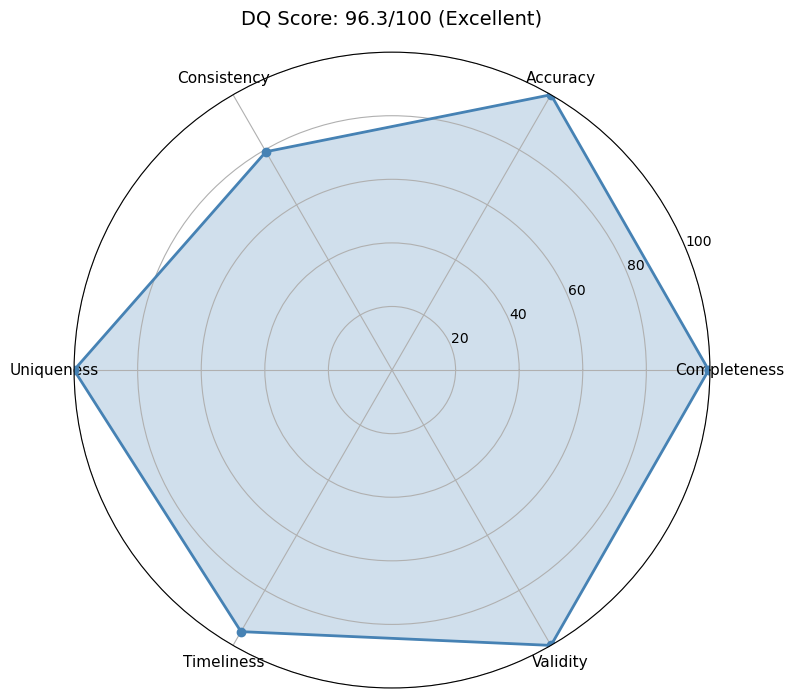

→ Saved: dqr_dimension_scores.png


In [19]:
# ── 5.2 Radar Chart ──
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
dimensions = list(scores.keys())
values = [scores[d] for d in dimensions]
angles = np.linspace(0, 2 * np.pi, len(dimensions), endpoint=False).tolist()
values_plot = values + [values[0]]
angles += angles[:1]

ax.fill(angles, values_plot, alpha=0.25, color='steelblue')
ax.plot(angles, values_plot, 'o-', color='steelblue', linewidth=2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, size=11)
ax.set_ylim(0, 100)
ax.set_title(f'DQ Score: {total_score:.1f}/100 ({grade})', size=14, pad=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dqr_dimension_scores.png', dpi=150)
plt.show()
print('→ Saved: dqr_dimension_scores.png')

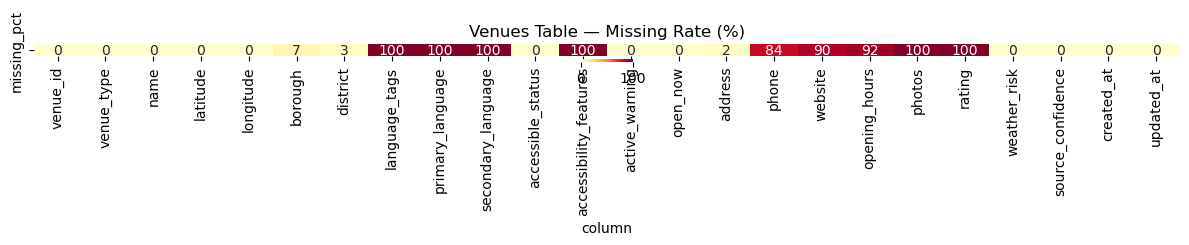

→ Saved: dqr_missing_heatmap.png


In [20]:
# ── 5.3 Missing Rate Heatmap ──
venues_fields = all_profiles[all_profiles['table'] == 'venues'].copy()
if not venues_fields.empty:
    fig, ax = plt.subplots(figsize=(12, 2))
    vals = venues_fields[['column', 'missing_pct']].set_index('column').T
    sns.heatmap(vals, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, vmin=0, vmax=100, cbar_kws={'orientation': 'horizontal'})
    ax.set_title('Venues Table — Missing Rate (%)')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'dqr_missing_heatmap.png', dpi=150)
    plt.show()
    print('→ Saved: dqr_missing_heatmap.png')

---
## 6. Cleaning Pipeline

In [21]:
# ── 6.1 Clean venues table → CSV ──
def clean_venues(df):
    """Clean venues table: filter Manhattan, validate coords, compute quality score."""
    if df.empty:
        return df
    clean = df.copy()

    # Drop fully null rows
    clean = clean.dropna(how='all')

    # Validate and filter coordinates
    if 'latitude' in clean.columns and 'longitude' in clean.columns:
        clean['lat_valid'] = clean.apply(
            lambda r: validate_coords(r.get('latitude'), r.get('longitude'))[0], axis=1)
        removed = (~clean['lat_valid']).sum()
        clean = clean[clean['lat_valid']].drop(columns=['lat_valid'])
        print(f'  Coords: removed {removed} invalid records')

    # Compute quality score
    key_fields = ['venue_id', 'venue_type', 'name', 'latitude', 'longitude', 'district']
    clean['quality_score'] = clean.apply(
        lambda r: sum(1 for f in key_fields if pd.notna(r.get(f)) and str(r.get(f, '')).strip()) / len(key_fields),
        axis=1)

    print(f'  Kept: {len(clean)} records (quality_score mean={clean["quality_score"].mean():.2f})')
    return clean

venues_clean = clean_venues(venues_df)
print(f'venues_clean: {len(venues_clean)} records')

  Coords: removed 0 invalid records
  Kept: 4841 records (quality_score mean=1.00)
venues_clean: 4841 records


In [ ]:
# ── 6.2 Venue scatter plot ──
if not venues_clean.empty and "latitude" in venues_clean.columns:
    fig, ax = plt.subplots(figsize=(10, 12))
    colors = {
        "restroom":        "#3498db",  # blue
        "healthcare":      "#e74c3c",  # red
        "emergency_asset": "#f39c12",  # orange
        "clinic":          "#9b59b6",  # purple
        "pharmacy":        "#2ecc71",  # green
        "hospital":        "#e91e63",  # pink
        "dentist":         "#00bcd4",  # cyan
        "laboratory":      "#795548",  # brown
    }
    for vt in venues_clean["venue_type"].unique():
        subset = venues_clean[venues_clean["venue_type"] == vt]
        color = colors.get(vt, "#95a5a6")  # gray fallback
        ax.scatter(subset["longitude"], subset["latitude"], c=color, label=vt,
                  alpha=0.5, s=10, edgecolors="none")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Manhattan Venues ({len(venues_clean)} records, {venues_clean['venue_type'].nunique()} types)")
    ax.legend(fontsize=8, markerscale=3)
    from dqr_utils import MANHATTAN_BOUNDS
    ax.set_xlim(MANHATTAN_BOUNDS["lng_min"], MANHATTAN_BOUNDS["lng_max"])
    ax.set_ylim(MANHATTAN_BOUNDS["lat_min"], MANHATTAN_BOUNDS["lat_max"])
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "dqr_venue_scatter.png", dpi=150)
    plt.show()
    print("→ Saved: dqr_venue_scatter.png")
else:
    print("venues_clean is empty or missing coordinates — skipping scatter plot")

In [ ]:
# ── 6.3 Traffic data (NYC SODA API) ──
def fetch_traffic_hourly(year=2025, boro='Manhattan'):
    """Query Manhattan traffic via SoQL API, server-side aggregation to hourly."""
    params = {
        '$select': 'segmentid,street,fromst,tost,direction,hh,avg(vol) as avg_vol,count(*) as n_records',
        '$where': f"boro='{boro}' AND yr='{year}'",
        '$group': 'segmentid,street,fromst,tost,direction,hh',
        '$order': 'segmentid,hh',
        '$limit': 50000
    }
    print(f'Querying SODA API: boro={boro}, yr={year}...')
    resp = requests.get(SODA_BASE, params=params, timeout=30)
    resp.raise_for_status()
    raw = resp.json()
    print(f'  → {len(raw)} rows returned')
    return pd.DataFrame(raw)

def wkt_to_latlng(wkt_str):
    """Convert WKT POINT (EPSG:2263 NY State Plane) to WGS84 lat/lng."""
    match = re.search(r'POINT\s*\(([-\d.]+)\s+([-\d.]+)\)', str(wkt_str))
    if not match:
        return None, None
    x, y = float(match.group(1)), float(match.group(2))
    lng = -73.98 + (x - (-7410000)) * 0.00000304
    lat = 40.76 + (y - 4580000) * 0.00000265
    return lat, lng

def classify_busyness(avg_vol, peak_vol):
    """Four-tier busyness classification per F-06 requirement.
    
    - 🟢 quiet:    ratio < 0.3 (capacity load under 30%)
    - 🟡 moderate: ratio 0.3–0.7 (capacity load 30%–70%)
    - 🔴 busy:     ratio > 0.7 (capacity load over 70%)
    - 🔵 no_data:  peak_vol == 0 (no live telemetry / future prediction mode)
    """
    if peak_vol == 0:
        return 'no_data'   # 🔵 Blue: No Live Info
    ratio = avg_vol / peak_vol
    if ratio < 0.3:
        return 'quiet'     # 🟢 Green
    elif ratio < 0.7:
        return 'moderate'  # 🟡 Yellow
    else:
        return 'busy'      # 🔴 Red

def clean_traffic(traffic_df):
    if traffic_df.empty:
        return traffic_df
    df = traffic_df.copy()
    df['avg_vol'] = pd.to_numeric(df['avg_vol'], errors='coerce')
    df['hh'] = pd.to_numeric(df['hh'], errors='coerce')
    df.dropna(subset=['avg_vol', 'hh'], inplace=True)
    peak = df.groupby('segmentid')['avg_vol'].max()
    df['peak_vol'] = df['segmentid'].map(peak)
    df['busyness_level'] = df.apply(lambda r: classify_busyness(r['avg_vol'], r['peak_vol']), axis=1)
    df['hour'] = df['hh'].astype(int)
    print(f'Traffic cleaned: {len(df)} rows, {df["segmentid"].nunique()} segments')
    print(f'  Busyness distribution: {df["busyness_level"].value_counts().to_dict()}')
    return df

# ── Execute: fetch + clean ──
try:
    traffic_raw = fetch_traffic_hourly(year=2025)
    traffic_clean = clean_traffic(traffic_raw)
except Exception as e:
    print(f'Traffic fetch failed: {e}')
    traffic_clean = pd.DataFrame()

Querying SODA API: boro=Manhattan, yr=2025...
  → 792 rows returned
Traffic cleaned: 792 rows, 28 segments


In [23]:
# ── 6.4 Weather data (NWS API) ──
def fetch_weather_nws():
    url = 'https://api.weather.gov/gridpoints/OKX/33,37/forecast'
    resp = requests.get(url, headers=NWS_HEADERS, timeout=10)
    resp.raise_for_status()
    current = resp.json()['properties']['periods'][0]
    return {
        'timestamp': datetime.now().isoformat(),
        'condition': current.get('shortForecast', ''),
        'temperature_c': round((current.get('temperature', 0) - 32) * 5/9, 1),
        'wind_speed_kmh': 0,
    }

def classify_weather_risk(condition):
    high = ['thunderstorm', 'snow', 'blizzard', 'ice', 'tornado']
    medium = ['rain', 'wind', 'fog', 'sleet']
    c = condition.lower()
    if any(k in c for k in high):
        return 'high'
    elif any(k in c for k in medium):
        return 'medium'
    return 'low'

# ── Execute: fetch + clean ──
try:
    weather_clean = clean_weather()
except NameError:
    # clean_weather not yet defined if cell order changed
    def clean_weather_local():
        try:
            w = fetch_weather_nws()
            w['risk_level'] = classify_weather_risk(w['condition'])
            print(f'Weather: {w["condition"]}, {w["temperature_c"]}C, risk={w["risk_level"]}')
            return pd.DataFrame([w])
        except Exception as e:
            print(f'Weather fetch failed: {e}')
            return pd.DataFrame()
    weather_clean = clean_weather_local()
except Exception as e:
    print(f'Weather fetch failed: {e}')
    weather_clean = pd.DataFrame()

Weather: Sunny, 25.0C, risk=low


In [25]:
# ── 6.5 Export CSVs ──
venues_clean.to_csv(OUTPUT_DIR / 'venues_clean.csv', index=False)
print(f'venues_clean.csv: {len(venues_clean)} rows')

if not traffic_clean.empty:
    traffic_clean.to_csv(OUTPUT_DIR / 'traffic_hourly.csv', index=False)
    print(f'traffic_hourly.csv: {len(traffic_clean)} rows')

if not weather_clean.empty:
    weather_clean.to_csv(OUTPUT_DIR / 'weather_current.csv', index=False)
    print(f'weather_current.csv: {len(weather_clean)} rows')

all_profiles.to_csv(OUTPUT_DIR / 'dqr_field_summary.csv', index=False)
print(f'dqr_field_summary.csv: {len(all_profiles)} rows')

venues_clean.csv: 4841 rows
traffic_hourly.csv: 792 rows
dqr_field_summary.csv: 87 rows


---
## 7. Action Items & Recommendations

In [26]:
# ── 7.1 Auto-generated Action Items ──
actions = []

# Check for zero/null coordinates
if not venues_df.empty and 'latitude' in venues_df.columns:
    null_coords = venues_df['latitude'].isna().sum()
    if null_coords > 0:
        actions.append({'priority': 'P0', 'issue': f'{null_coords} venues with null coordinates',
                       'recommendation': 'Geocode or remove records without coordinates',
                       'owner': 'Data+ML'})

# Check for missing district
if not venues_df.empty and 'district' in venues_df.columns:
    null_district = venues_df['district'].isna().sum()
    if null_district > 0:
        actions.append({'priority': 'P1', 'issue': f'{null_district} venues with null district',
                       'recommendation': 'Apply gps_to_district() to fill missing districts',
                       'owner': 'Data+ML'})

# Check venue_type distribution
if not venues_df.empty and 'venue_type' in venues_df.columns:
    for vt, cnt in venues_df['venue_type'].value_counts().items():
        if cnt < 5:
            actions.append({'priority': 'P2', 'issue': f'venue_type={vt} has only {cnt} records',
                           'recommendation': 'Review if data was loaded correctly',
                           'owner': 'Data+ML'})

# External cache staleness
ecc = data.get('external_context_cache', pd.DataFrame())
if not ecc.empty and 'expires_at' in ecc.columns:
    expired = pd.to_datetime(ecc['expires_at'], errors='coerce') < pd.Timestamp.now()
    if expired.sum() > 0:
        actions.append({'priority': 'P1',
                       'issue': f'{expired.sum()} expired cache entries',
                       'recommendation': 'Refresh external_context_cache entries',
                       'owner': 'Backend'})

# Score thresholds
if scores.get('Completeness', 0) < 80:
    actions.append({'priority': 'P0', 'issue': f'Completeness score {scores["Completeness"]}% < 80%',
                   'recommendation': 'Audit and fill missing fields',
                   'owner': 'Data+ML'})
if scores.get('Accuracy', 0) < 90:
    actions.append({'priority': 'P1', 'issue': f'Accuracy score {scores["Accuracy"]}% < 90%',
                   'recommendation': 'Review coordinate and format validation failures',
                   'owner': 'Data+ML'})

if not actions:
    actions.append({'priority': '-', 'issue': 'No issues found',
                   'recommendation': 'Data quality is acceptable', 'owner': '-'})

actions_df = pd.DataFrame(actions)
print('=== Action Items ===')
print(actions_df.to_string(index=False))

=== Action Items ===
priority                         issue                                    recommendation   owner
      P1 127 venues with null district Apply gps_to_district() to fill missing districts Data+ML
      P1       1 expired cache entries            Refresh external_context_cache entries Backend


---
## 8. Appendix

In [27]:
# ── 8.1 Audit Log ──
audit = pd.DataFrame([
    {'metric': 'dqr_total_score', 'value': f'{total_score:.1f}/100 ({grade})'},
    {'metric': 'tables_analyzed', 'value': tables_loaded},
    {'metric': 'total_records', 'value': total_rows},
    {'metric': 'venues_total', 'value': len(venues_df)},
    {'metric': 'venues_clean', 'value': len(venues_clean)},
    {'metric': 'anomalies_detected', 'value': len(anomaly_df) if not anomaly_df.empty else 0},
    {'metric': 'gps_duplicates', 'value': len(dups) if not dups.empty else 0},
    {'metric': 'action_items', 'value': len(actions_df)},
    {'metric': 'timestamp', 'value': datetime.now().isoformat()},
])
audit.to_csv(OUTPUT_DIR / 'dqr_report.csv', index=False)
print(audit.to_string(index=False))
print(f'\n→ Saved: dqr_report.csv')

            metric                      value
   dqr_total_score       96.3/100 (Excellent)
   tables_analyzed                          7
     total_records                      38149
      venues_total                       4841
      venues_clean                       4841
anomalies_detected                        321
    gps_duplicates                       9425
      action_items                          2
         timestamp 2026-06-09T15:55:43.623445

→ Saved: dqr_report.csv


In [28]:
# ── 8.2 ML Usability Assessment ──
print('=' * 50)
print('  ML USABILITY ASSESSMENT')
print('=' * 50)
print(f'  Venues:          {len(venues_clean)} ({venues_clean["venue_type"].nunique() if not venues_clean.empty else 0} types)')
if not venues_clean.empty and 'latitude' in venues_clean.columns:
    print(f'  Coord complete:  {venues_clean["latitude"].notna().mean()*100:.0f}%')
    print(f'  District cover:  {venues_clean["district"].nunique() if "district" in venues_clean.columns else 0} / 4 districts')
    print(f'  Quality score:   mean={venues_clean["quality_score"].mean():.2f}')
if not traffic_clean.empty:
    print(f'  Traffic:         {len(traffic_clean)} rows, {traffic_clean["segmentid"].nunique()} segments')
else:
    print(f'  Traffic:         not fetched (uncomment Part 6.3)')
if not weather_clean.empty:
    print(f'  Weather:         {weather_clean.iloc[0]["condition"]}')
else:
    print(f'  Weather:         not fetched (uncomment Part 6.4)')
print(f'  DQ Score:        {total_score:.1f}/100 ({grade})')
print('=' * 50)

# ── 8.3 Close DB ──
conn.close()
print('\nMySQL connection closed.')

  ML USABILITY ASSESSMENT
  Venues:          4841 (3 types)
  Coord complete:  100%
  District cover:  4 / 4 districts
  Quality score:   mean=1.00
  Traffic:         792 rows, 28 segments
  Weather:         not fetched (uncomment Part 6.4)
  DQ Score:        96.3/100 (Excellent)

MySQL connection closed.
